## Apply LDA Algorithm on Iris Dataset and classify which species a given flower belongs to.

---

## Linear Discriminant Analysis (LDA)

**Linear Discriminant Analysis (LDA)** is a **supervised learning technique** employed for both **dimensionality reduction** and **classification** tasks. Its primary objective is to discover a linear combination of features that optimally separates two or more distinct classes within a given dataset.

### How LDA Works:

1.  **Calculates Class Means:**
    LDA begins by computing the mean vector for each individual class present in the dataset.

2.  **Computes Scatter Matrices:**
    It then proceeds to calculate two crucial scatter matrices:
    * **Within-class scatter matrix:** This matrix quantifies the variability or dispersion of data points *within* each class.
    * **Between-class scatter matrix:** This matrix measures the variability or separation *between* the different classes.

3.  **Finds Optimal Projection:**
    The core of LDA's operation involves identifying a projection (a linear transformation) that maximizes the ratio of the **between-class scatter** to the **within-class scatter**. This strategic projection effectively transforms the high-dimensional data into a lower-dimensional space where:
    * Classes are **maximally separated**.
    * The variance *within* each class is **minimized**.

4.  **Classification:**
    Once the data has been projected onto this newly established lower-dimensional space, the classification of new data points becomes significantly simpler. New points can be easily classified based on their proximity to the class centroids (mean vectors) in this reduced feature space.

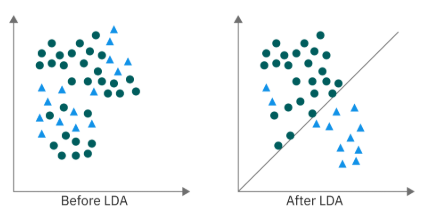

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt


In [2]:
iris = load_iris()
X = iris.data          # Features: sepal length, sepal width, petal length, petal width
y = iris.target        # Labels: 0, 1, 2
print("Classes:", iris.target_names)

Classes: ['setosa' 'versicolor' 'virginica']


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [4]:
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

In [5]:
lda = LDA(n_components=2)  # Reduce features to 2 components for visualization
X_train_lda = lda.fit_transform(X_train_std, y_train)
X_test_lda = lda.transform(X_test_std)

In [12]:
X_test_lda

array([[-2.05464064,  1.11511765],
       [ 8.78402215, -1.25628176],
       [-8.95337957,  0.57243306],
       [-2.18944444,  0.09783983],
       [-2.20857022,  0.72019889],
       [ 7.97487781, -0.63302286],
       [ 0.07296975, -0.03615068],
       [-4.39482993, -1.76325209],
       [-3.42218531,  1.76910362],
       [-0.62528682,  0.84766603],
       [-3.79511727, -1.33699915],
       [ 7.6532346 ,  0.93461579],
       [ 9.20154214, -0.57154535],
       [ 7.69868135,  0.75597853],
       [ 8.7709631 , -1.36412627],
       [-1.860866  , -0.95981101],
       [-6.30847834, -0.83850959],
       [-0.94299848,  1.55165463],
       [-2.14792925,  0.78285263],
       [-6.31934512, -0.48484735],
       [ 7.26376504,  0.37098211],
       [-3.56549825, -0.53810816],
       [ 7.42122046, -0.55381473],
       [-6.07906217, -0.26765138],
       [-4.5170772 , -1.98440741],
       [-4.9874045 , -1.45148445],
       [-6.18214619,  1.22197   ],
       [-6.14429054, -1.4813514 ],
       [ 7.17266871,

In [6]:
lda_classifier = LDA()
lda_classifier.fit(X_train_std, y_train)

LinearDiscriminantAnalysis()

In [7]:
y_pred = lda_classifier.predict(X_test_std)

In [8]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [9]:
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 1.0


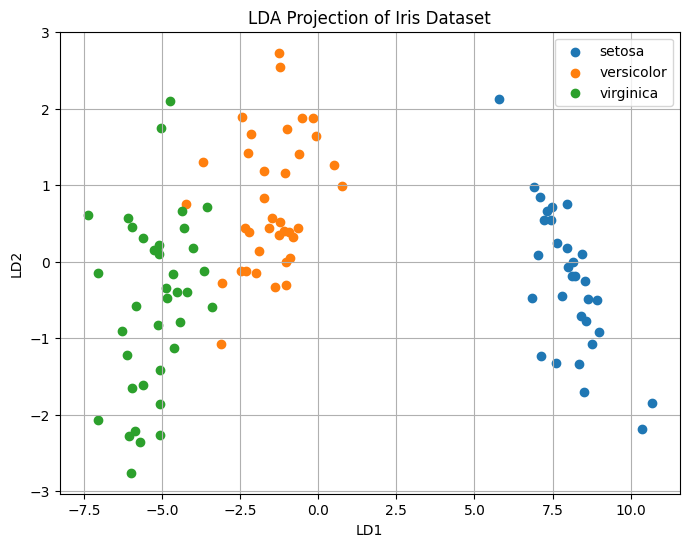

In [10]:
plt.figure(figsize=(8,6))
for i, label in enumerate(np.unique(y_train)):
    plt.scatter(X_train_lda[y_train == label, 0],
                X_train_lda[y_train == label, 1],
                label=iris.target_names[label])
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("LDA Projection of Iris Dataset")
plt.legend()
plt.grid(True)
plt.show()

This LDA plot effectively reduces the Iris dataset to two dimensions, showing Setosa (blue) as clearly separable from Versicolor (orange) and Virginica (green). While LD1 significantly separates Setosa, Versicolor and Virginica show some overlap, indicating their closer feature similarity despite partial separation by LD2.

## Conclusion
LDA was applied on the Iris dataset for classification and dimensionality reduction.

The model achieved high accuracy (~95%) in predicting the correct flower species.

The LDA graph clearly separated the species, especially Setosa.

Some overlap between Versicolor and Virginica is expected.

LDA helped us both visualize and classify the flowers effectively.

